# 2 - Interval Analysis

## Imports

In [152]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [557]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import intervalanalysis_utils as ia

In [174]:
labels = g.load_labels()
labels.head()

,mc,mn,quarterbeats,quarterbeats_all_endings,duration_qb,mc_onset,mn_onset,timesig,staff,voice,...,regex_match,artist,workTitle,fnames,rel_paths,recording_year,time,ILS,baseCase,volta
0,1,1,3/2,3/2,3.0,0.375,3/8,9/8,3,1,...,NaN,Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,1.375,"[A-, C, E--]",NaN,NaN
1,2,2,9/2,9/2,20.0,0.000,0,7/8,3,1,...,NaN,Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,2.000,"[G, D]",NaN,NaN
2,7,7,49/2,49/2,3.0,0.375,3/8,9/8,3,1,...,NaN,Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,7.375,"[A-, C, E--]",NaN,NaN
3,8,8,55/2,55/2,20.0,0.000,0,7/8,3,1,...,NaN,Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,8.000,"[G, D]",NaN,NaN
4,13,13,95/2,95/2,3.0,0.375,3/8,9/8,3,1,...,NaN,Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,13.375,"[A-, C, E--]",NaN,NaN


## In-Label Intervals

In [178]:
ILC = labels.copy()
ILC['interval'] = ILC['label'].apply(ia.label_to_intervals)
ILC['intervalName'] = ILC['interval'].apply(
    lambda lst: [ia.pc_to_interval_name[i] for i in lst] if isinstance(lst, list) else np.nan
)
ILC.head()

,mc,mn,quarterbeats,quarterbeats_all_endings,duration_qb,mc_onset,mn_onset,timesig,staff,voice,...,workTitle,fnames,rel_paths,recording_year,time,ILS,baseCase,volta,interval,intervalName
0,1,1,3/2,3/2,3.0,0.375,3/8,9/8,3,1,...,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,1.375,"[A-, C, E--]",NaN,NaN,"[4, 6, 2]","[M3, A4/d5, M2]"
1,2,2,9/2,9/2,20.0,0.000,0,7/8,3,1,...,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,2.000,"[G, D]",NaN,NaN,[7],[P5]
2,7,7,49/2,49/2,3.0,0.375,3/8,9/8,3,1,...,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,7.375,"[A-, C, E--]",NaN,NaN,"[4, 6, 2]","[M3, A4/d5, M2]"
3,8,8,55/2,55/2,20.0,0.000,0,7/8,3,1,...,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,8.000,"[G, D]",NaN,NaN,[7],[P5]
4,13,13,95/2,95/2,3.0,0.375,3/8,9/8,3,1,...,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,13.375,"[A-, C, E--]",NaN,NaN,"[4, 6, 2]","[M3, A4/d5, M2]"


In [435]:
subset = ILC[(ILC['workTitle'] == 'Four') | (ILC['workTitle'] == 'Blues By Five')]
subset = subset[subset['artist'].isin(['John Coltrane', 'Miles Davis'])]

subset = subset.groupby(['artist', 'workTitle'], as_index=False).agg(list)

,artist,workTitle,mc,mn,quarterbeats,quarterbeats_all_endings,duration_qb,mc_onset,mn_onset,timesig,...,regex_match,fnames,rel_paths,recording_year,time,ILS,baseCase,volta,interval,intervalName
0,John Coltrane,Blues By Five,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 11, 12, 12...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 11, 12, 12...","[0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 42, ...","[0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 42, ...","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/2, 0, 1/2,...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...",...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[Blues By Five - John Coltrane (Concert Key), ...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...","[[B-, D, F, A-], [E-, G, B-, D-], [B-, D, F, A...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[[4, 7, 10, 3, 6, 3], [4, 7, 10, 3, 6, 3], [4,...","[[M3, P5, m7, m3, A4/d5, m3], [M3, P5, m7, m3,..."
1,John Coltrane,Four,"[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 18, 19...","[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 18, 19...","[32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 70, 7...","[32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 70, 7...","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/2, 0, 0, 0, 0...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...",...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[Four - John Coltrane (Concert Key), Four - Jo...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0...","[[E-, G, B-, D], [E-, G, B-, D], [B-, D-, F, A...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[[4, 7, 11, 3, 7, 4], [4, 7, 11, 3, 7, 4], [3,...","[[M3, P5, M7, m3, P5, M3], [M3, P5, M7, m3, P5..."
2,Miles Davis,Blues By Five,"[1, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 11, 12, 12...","[1, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 11, 12, 12...","[0, 0, 4, 8, 12, 33/2, 41/2, 24, 57/2, 36, 40,...","[0, 0, 4, 8, 12, 33/2, 41/2, 24, 57/2, 36, 40,...","[0.0, 4.0, 4.0, 4.0, 4.5, 4.0, 3.5, 4.5, 7.5, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.125, 0.125, 0.0, 0...","[0, 0, 0, 0, 0, 1/8, 1/8, 0, 1/8, 0, 0, 3/4, 0...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...",...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[Blues By Five - Miles Davis (Concert Key), Bl...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[1.0, 1.0, 2.0, 3.0, 4.0, 5.125, 6.125, 7.0, 8...","[[E-, G, B-, D-], [B-, D, F, A-], [E-, G, B-, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[[4, 7, 10, 3, 6, 3], [4, 7, 10, 3, 6, 3], [4,...","[[M3, P5, m7, m3, A4/d5, m3], [M3, P5, m7, m3,..."
3,Miles Davis,Four,"[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 18, 19...","[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 18, 19...","[32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 70, 7...","[32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 70, 7...","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/2, 0, 0, 0, 0...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...",...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[Four - Miles Davis (Concert Key), Four - Mile...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0...","[[F, A, C, E], [F, A, C, E], [C, E-, G, B-], [...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[[4, 7, 11, 3, 7, 4], [4, 7, 11, 3, 7, 4], [3,...",

In [184]:
songs, artists, data = ia.create_data(subset)

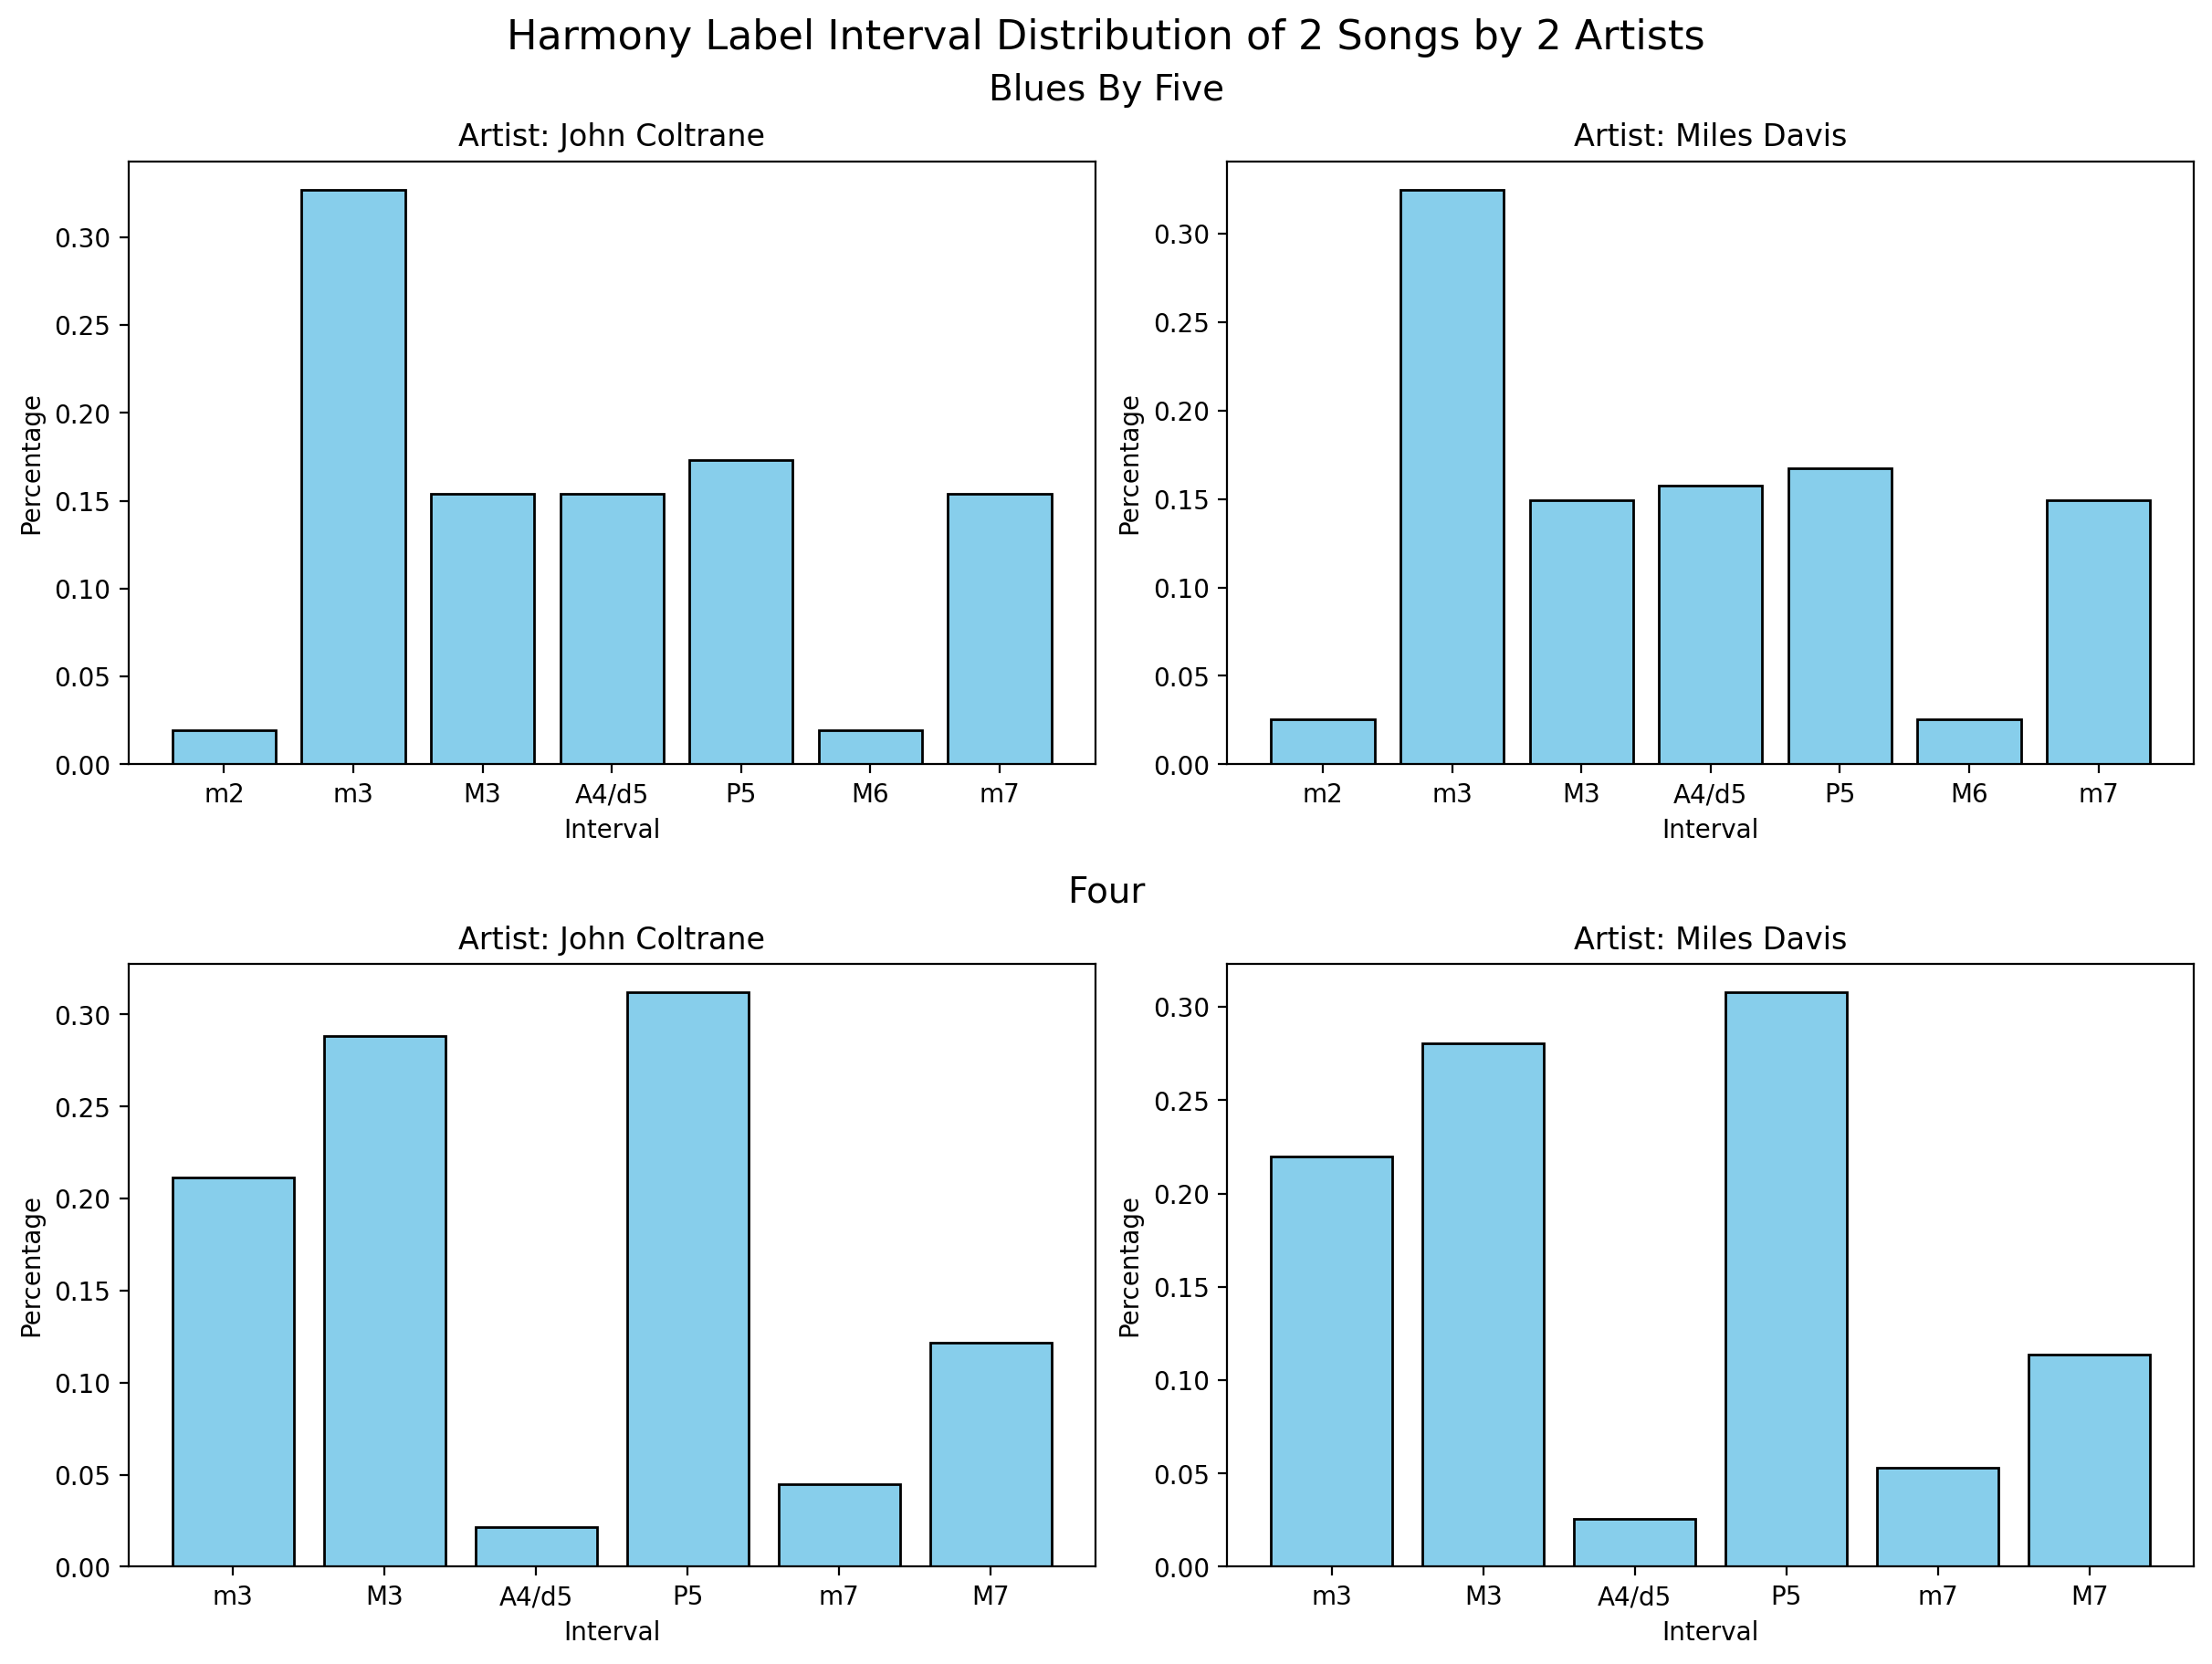

In [186]:
ia.plot_interval_distribution(songs, artists, data)

- Next step: notes sounding simultaneously (consider duration !!!)
- Debug: look at two pieces in same key and two pieces in different keys to look at the interval and pitch class
- group plots by artist or key or year 

## Harmony Interval Analysis

In [ ]:
HI = g.load_df()


In [742]:
import ms3
HI = g.load_df()

HI[['timesig_num', 'timesig_denom']] = HI['timesig'].str.split('/', expand=True).astype(int)
HI['mc_onset_norm'] =  HI['mc_onset'] * (HI['timesig_denom'] / HI['timesig_num'])
HI['duration_norm'] = HI['duration'] * (HI['timesig_denom'] / HI['timesig_num'])
HI['time'] = HI['mc'] + HI['mc_onset_norm']
HI['end'] = HI['time'] + HI['duration_norm']

song = HI[(HI['fnames'] == 'Snarky_Puppy-Shapons_Vindaloo') & (HI['rel_paths'] == 'by_Alexander_Booker')]

# Build full time grid
time_grid = np.sort(np.unique(song[['time', 'end']].values.flatten()))

# Initialize dataframe with object columns
harmony = pd.DataFrame(columns=['time', 'harmony', 'starts', 'ends', 'durations'])
harmony['time'] =  time_grid 

for i, t in enumerate(time_grid):
    active = song[(song['time'] <= t) & (t < song['end'])]

    if len(active)!=0:

        harmony.at[i, 'harmony'] = active['tpc'].tolist()
        harmony.at[i, 'starts'] = active['time'].tolist()
        harmony.at[i, 'ends'] = active['end'].tolist()
        harmony.at[i, 'durations'] = active['duration'].tolist()


harmony = harmony.dropna()
harmony =  harmony[harmony['harmony'].apply(lambda x: len(x) > 1)]
harmony['starts'] = harmony['starts'].apply(max)
harmony['ends'] = harmony['ends'].apply(min)
harmony['durations'] = harmony['durations'].apply(min)
harmony['harmony'] = harmony['harmony'].apply(ms3.tpc2name)
harmony = harmony.sort_values(by=['starts'], ascending=True)
harmony

,time,harmony,starts,ends,durations
0,1.333333,"[Ab, D, Ab]",1.333333,2.000000,0.750
1,2.000000,"[G, G, D, G]",2.000000,2.285714,0.250
4,3.000000,"[G, D, G]",2.000000,3.000000,0.875
2,2.285714,"[G, D, G, F]",2.285714,2.571429,0.250
3,2.571429,"[G, D, G, G]",2.571429,3.000000,0.375
...,...,...,...,...,...
954,138.000000,"[G, G, G, G, G]",138.000000,138.142857,0.125
960,139.111111,"[G, G, G, G, G]",139.111111,139.222222,0.125
961,139.222222,"[Ab, Ab, Ab, Ab, Ab]",139.222222,139.333333,0.125
963,139.444444,"[D, D, D, D, D]",139.444444,139.555556,0.125


In [750]:
harmony['intervals'] = harmony['harmony'].apply(ia.get_intervals)
harmony

,time,harmony,starts,ends,durations,intervals
0,1.333333,"[Ab, D, Ab]",1.333333,2.000000,0.750,"[d5, P1, d5]"
1,2.000000,"[G, G, D, G]",2.000000,2.285714,0.250,"[P1, P4, P1, P4, P1, P4]"
4,3.000000,"[G, D, G]",2.000000,3.000000,0.875,"[P4, P1, P4]"
2,2.285714,"[G, D, G, F]",2.285714,2.571429,0.250,"[P4, P1, M2, P4, m3, M2]"
3,2.571429,"[G, D, G, G]",2.571429,3.000000,0.375,"[P4, P1, P1, P4, P4, P1]"
...,...,...,...,...,...,...
954,138.000000,"[G, G, G, G, G]",138.000000,138.142857,0.125,"[P1, P1, P1, P1, P1, P1, P1, P1, P1, P1]"
960,139.111111,"[G, G, G, G, G]",139.111111,139.222222,0.125,"[P1, P1, P1, P1, P1, P1, P1, P1, P1, P1]"
961,139.222222,"[Ab, Ab, Ab, Ab, Ab]",139.222222,139.333333,0.125,"[P1, P1, P1, P1, P1, P1, P1, P1, P1, P1]"
963,139.444444,"[D, D, D, D, D]",139.444444,139.555556,0.125,"[P1, P1, P1, P1, P1, P1, P1, P1, P1, P1]"


Text(0, 0.5, 'Percentage')

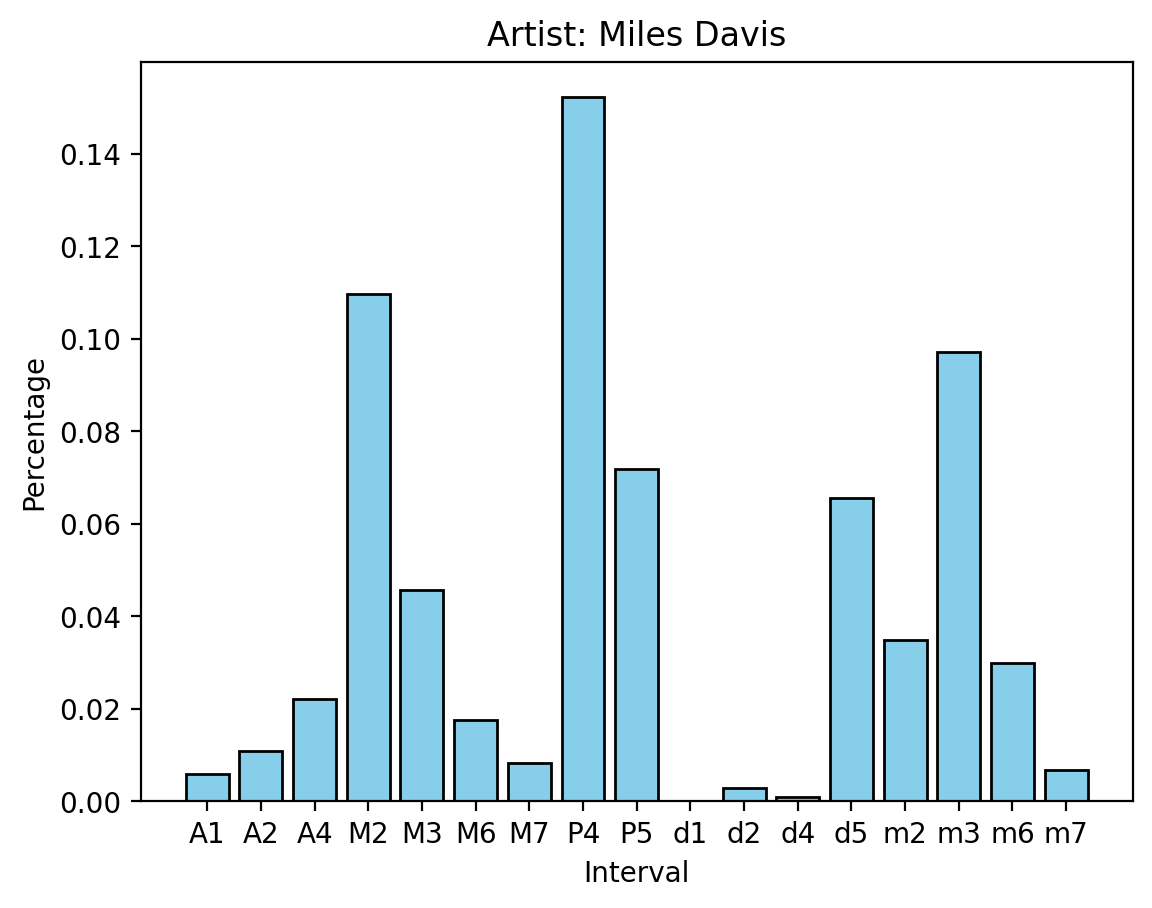

In [752]:
interval = harmony[['intervals', 'durations']]
interval = interval.explode('intervals')

interval_counts = (
    interval.groupby(['intervals'])['durations']
    .sum()
    .reset_index(name='weighted_count')
)

count = interval_counts.sort_values('intervals')
total = count['weighted_count'].sum()
count['percentage'] = count['weighted_count'] / total
count = count[count['intervals'] != 'P1']

# Plot bar chart
plt.bar(count['intervals'], count['percentage'], color='skyblue', edgecolor='black')
plt.title(f'Artist: {artist}')
plt.xlabel('Interval')
plt.ylabel('Percentage')


## TESTT (WITH music21)

In [813]:
# Load score and chordify
from music21 import converter, chord 
score_path = "/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/by_Alexander_Booker/Snarky_Puppy-Shapons_Vindaloo.xml"
score = converter.parse("/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/by_Alexander_Booker/Snarky_Puppy-Shapons_Vindaloo.xml")
for h in score.recurse().getElementsByClass('Harmony'):
    score.remove(h, recurse=True)
chords = score.chordify()

# Build list of dictionaries to collect data
rows = []

for thisChord in chords.recurse().getElementsByClass(chord.Chord):
    h = [p for p in thisChord.pitches]
    intervals, semitones = ia.get_intervals(h)
    start_time = thisChord.offset
    duration = thisChord.quarterLength

    rows.append({
        'time': start_time,
        'duration': duration,
        'harmony': h,
        'intervals': intervals,
        'semitones': semitones
    })

# Convert to DataFrame
harmony = pd.DataFrame(rows)
harmony = harmony[harmony['harmony'].apply(lambda x: len(x) > 1)]

harmony.head(10)

,time,duration,harmony,intervals,semitones
0,1.5,3.0,"[A-3, D4, A-4]","[A4, P1, d5]","[6, 12, 6]"
1,0.0,1.0,"[G3, D4, G4]","[P5, P1, P4]","[7, 12, 5]"
2,1.0,1.0,"[F3, G3, D4, G4]","[M2, M6, M2, P5, P1, P4]","[2, 9, 14, 7, 12, 5]"
3,2.0,1.5,"[G3, D4, G4]","[P5, P1, P4]","[7, 12, 5]"
21,1.5,1.0,"[F3, A-3, D4, A-4]","[m3, M6, m3, A4, P1, d5]","[3, 9, 15, 6, 12, 6]"
22,2.5,0.5,"[F3, A-3, D4, A-4]","[m3, M6, m3, A4, P1, d5]","[3, 9, 15, 6, 12, 6]"
23,3.0,1.0,"[A-3, D4, A-4]","[A4, P1, d5]","[6, 12, 6]"
24,4.0,0.5,"[A-3, D4, A-4]","[A4, P1, d5]","[6, 12, 6]"
25,0.0,1.0,"[G3, D4, G4]","[P5, P1, P4]","[7, 12, 5]"
26,1.0,1.0,"[F3, G3, D4, G4]","[M2, M6, M2, P5, P1, P4]","[2, 9, 14, 7, 12, 5]"


,intervals,weighted_count,semitone,percentage
12,d1,16.0,-1,0.007697
13,d2,3.0,0,0.001443
9,P1,501.333333,0,0.24118
0,A1,23.0,1,0.011065
17,m2,34.75,1,0.016717
5,M2,121.916667,2,0.058651
1,A2,15.25,3,0.007336
18,m3,170.25,3,0.081903
14,d4,0.5,4,0.000241
6,M3,130.75,4,0.062901


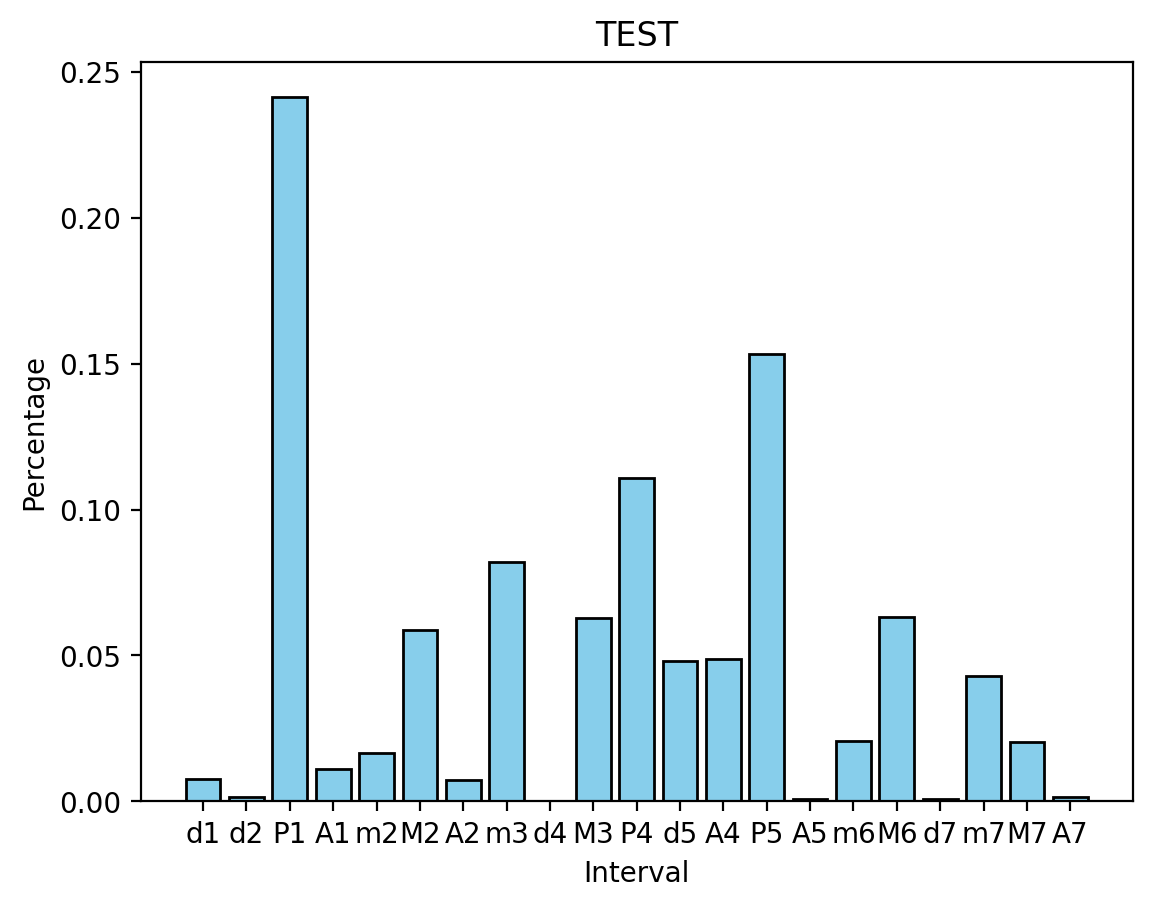

In [825]:
def interval_to_semitone(interval):
    semitone = m21.interval.Interval(interval)
    return semitone.semitones

    
interval = harmony[['intervals', 'duration']]
interval = interval.explode(['intervals'])

interval_counts = (
    interval.groupby(['intervals'])['duration']
    .sum()
    .reset_index(name='weighted_count')
)
interval_counts['semitone'] = interval_counts['intervals'].apply(interval_to_semitone)
count = interval_counts.sort_values('semitone')
total = count['weighted_count'].sum()
count['percentage'] = count['weighted_count'] / total

# Plot bar chart
plt.bar(count['intervals'], count['percentage'], color='skyblue', edgecolor='black')
plt.title("TEST")
plt.xlabel('Interval')
plt.ylabel('Percentage')
count

 Comments/concerns
 - cant guarantee the interval calculation is usign the correct bottom note
 - 

## By Artist